In [2]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
from numpy import *
import seaborn as sns
from sklearn import preprocessing

def max2(x):
    if len(x)==1: return x[0]
    if len(x)==2: return max(x)
    x2 = x.copy()#复制一份，不破坏原来的列表
    x2.sort()#从小到大排序
    m1 = x2[-1]#最后一个元素最大
    m2 = x2[-2]#倒数第二个元素第二大
    return (m2+m1)/2  #m1是第二大的值,m2是最大值
def onetwo(l):
    # 找到最小值
    min_value = min(l)
    # 将列表中的最小值替换为1，其余替换为2
    result_list = [1 if x == min_value else 2 for x in l if x is not None]
    return(result_list)


# BurstSize

In [5]:

genelist = ['FOS']
burstsize={}
for i in genelist:
    burstsize[i] = []
    
burstsize_scale={}
for i in genelist:
    burstsize_scale[i] = []

burstsize_zscore={}
for i in genelist:
    burstsize_zscore[i] = []

burstsize_robust={}
for i in genelist:
    burstsize_robust[i] = []

burstsize_median={}
for i in genelist:
    burstsize_median[i] = []

burstsize_background={}
for i in genelist:
    burstsize_background[i] = []
    
burstsize_mean={}
for i in genelist:
    burstsize_mean[i] = []

burstsize_sum={}
for i in genelist:
    burstsize_sum[i] = []
#values = np.array(d)
#data = z_score_normalize(values) 
#data = preprocessing.scale(np.array(d))  

In [7]:
for i in glob(r'trace/*_hmm2states.csv'):
    gene = 'FOS'
    if 2:
        file = i
        trace = pd.read_csv(file)
        hmm_seq = "".join([str(string) for string in list(trace['HMMStates'])])
        sequence = hmm_seq
        intensity = list(trace['photon_number'])
        #off state
        background=[]
        matches = re.finditer(r'1+', sequence)
        for match in matches:
            start = match.start()
            end = match.end()
            background += intensity[start:end]
        #on state
        burst=[]
        matches = re.finditer(r'2+', sequence)
        for match in matches:
            start = match.start()
            end = match.end()
            period = intensity[start:end]
            m1m2 = max2(period)
            burst.append(m1m2-mean(background))
            burstsize[gene].append(m1m2-mean(background))
        if len(burst)==0 : continue
        else: 
            burstsize_scale[gene] +=[(x-min(burst))/(max(burst)-min(burst)) for x in burst]
            burstsize_zscore[gene] +=list(preprocessing.scale(np.array(burst)))
            burstsize_robust[gene] += [list(x)[0] for x in preprocessing.RobustScaler().fit([[x] for x in burst]).transform([[x] for x in burst])]
            burstsize_mean[gene] +=[x/mean(burst) for x in burst]
            burstsize_median[gene] +=[x/median(burst) for x in burst]
            burstsize_background[gene] +=[x/mean(background) for x in burst]


C:\Users\WanLab Administrator\AppData\Local\Temp\ipykernel_21116\663707761.py:28: RuntimeWarning: invalid value encountered in scalar divide
  burstsize_scale[gene] +=[(x-min(burst))/(max(burst)-min(burst)) for x in burst]
C:\Users\WanLab Administrator\AppData\Local\Temp\ipykernel_21116\663707761.py:28: RuntimeWarning: invalid value encountered in scalar divide
  burstsize_scale[gene] +=[(x-min(burst))/(max(burst)-min(burst)) for x in burst]
C:\Users\WanLab Administrator\AppData\Local\Temp\ipykernel_21116\663707761.py:28: RuntimeWarning: invalid value encountered in scalar divide
  burstsize_scale[gene] +=[(x-min(burst))/(max(burst)-min(burst)) for x in burst]
C:\Users\WanLab Administrator\AppData\Local\Temp\ipykernel_21116\663707761.py:28: RuntimeWarning: invalid value encountered in scalar divide
  burstsize_scale[gene] +=[(x-min(burst))/(max(burst)-min(burst)) for x in burst]
C:\Users\WanLab Administrator\AppData\Local\Temp\ipykernel_21116\663707761.py:28: RuntimeWarning: invalid va

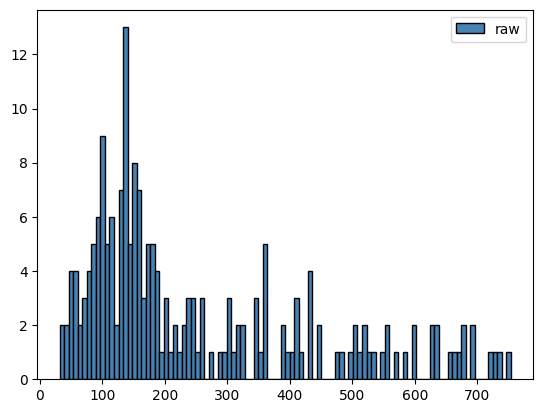

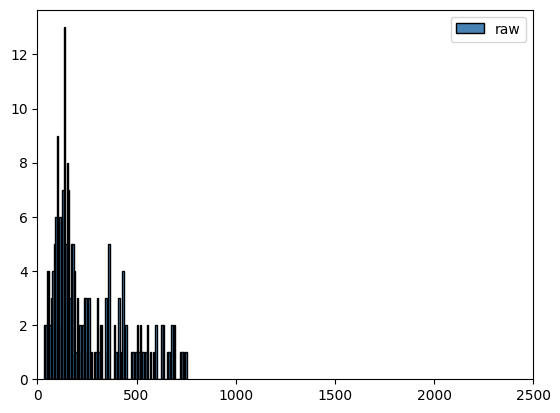

In [10]:
os.chdir(r'result/')
#原始
for i in genelist:
    plt.figure(300)
    plt.hist(burstsize[i], # 绘图数据
        #bins=max([int(x) for x in burstsize[i]])+1, # 指定直方图的条形数为20个
        bins = 100,
        color = 'steelblue', # 指定填充色
        edgecolor = 'k', # 指定直方图的边界色
        label = 'raw' )# 为直方图呈现标签
    plt.legend()
    #plt.xlim(0,3000) #设置横轴范围为0到4
    plt.savefig('plot/burstsize-{}.png'.format(i))
    plt.show()

for i in genelist:
    plt.figure(300)
    plt.hist(burstsize[i], # 绘图数据
        #bins=max([int(x) for x in burstsize[i]])+1, # 指定直方图的条形数为20个
        bins = 100,
        color = 'steelblue', # 指定填充色
        edgecolor = 'k', # 指定直方图的边界色
        label = 'raw' )# 为直方图呈现标签
    plt.legend()
    plt.xlim(0,2500) #设置横轴范围为0到4
    plt.savefig('plot/burstsize-{}-range2500.png'.format(i))
    plt.show()
burstsizedf = pd.DataFrame.from_dict(burstsize, orient='index')
burstsizedf = burstsizedf.T
burstsizedf.to_csv('distribution-burstsize(raw).csv',index=None)

In [12]:
burstsizedf.to_csv('raw-values.csv',index=None)

In [18]:
intensity = pd.read_csv('distribution-burstsize(raw).csv')
bs = intensity/intensity.median(axis=None)
bs.to_csv('distribution-burstsize(median).csv',index=None)

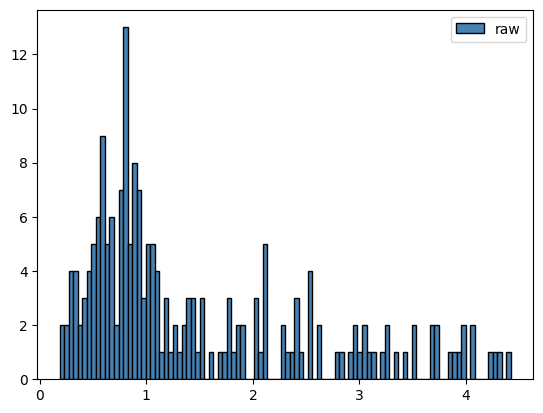

In [20]:
for i in genelist:
    plt.figure(300)
    plt.hist(bs[i], # 绘图数据
        #bins=max([int(x) for x in burstsize[i]])+1, # 指定直方图的条形数为20个
        bins = 100,
        color = 'steelblue', # 指定填充色
        edgecolor = 'k', # 指定直方图的边界色
        label = 'raw' )# 为直方图呈现标签
    plt.legend()
    #plt.xlim(0,3000) #设置横轴范围为0到4
    plt.savefig('./plot/burstsize-NormalizedByMean-{}.png'.format(i))
    plt.show()


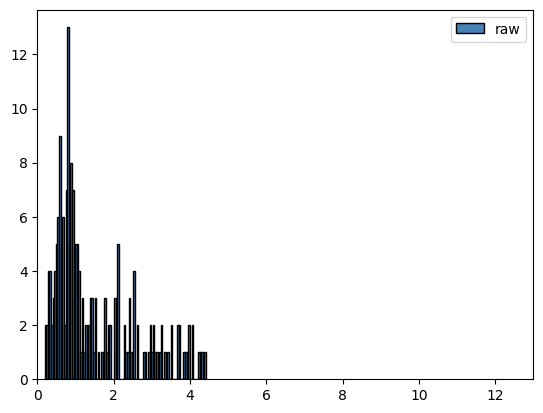

In [22]:
for i in genelist:
    plt.figure(300)
    plt.hist(bs[i], # 绘图数据
        #bins=max([int(x) for x in burstsize[i]])+1, # 指定直方图的条形数为20个
        bins = 100,
        color = 'steelblue', # 指定填充色
        edgecolor = 'k', # 指定直方图的边界色
        label = 'raw' )# 为直方图呈现标签
    plt.legend()
    plt.xlim(0,13) #设置横轴范围为0到4
    plt.savefig('./plot/burstsize-NormalizedByMean-{}-range2500.png'.format(i))
    plt.show()